Loading best model from best_model.pth...
Running inference on the validation set...
1


c:\Users\veerk\OneDrive\Desktop\DIP Project\dip\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\veerk\OneDrive\Desktop\DIP Project\stats\main_work.py:70: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
c:\Users\veerk\OneDrive\Desktop\DIP Project\dip\Lib\site-packages\torch\amp\autocast_mode.py:266: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(



--- Generating Visualizations ---
Skipped: Training/Validation Curves (No history data provided).


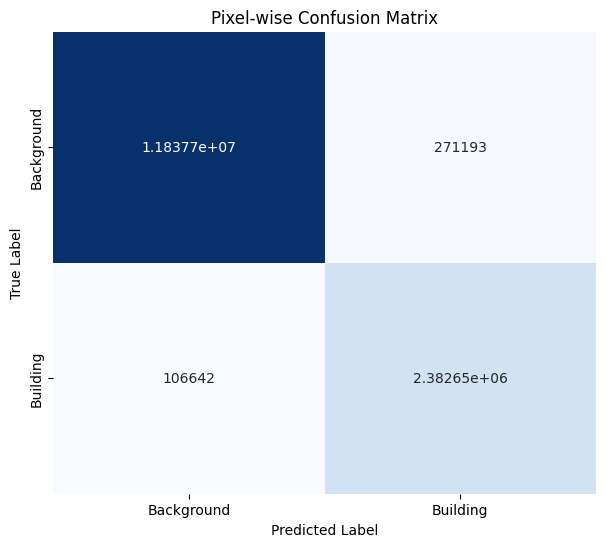

Generated: Confusion Matrix

--- Quantitative Metrics Summary (on Validation Set) ---
Overall Pixel Accuracy: 0.9741
Overall IoU (Jaccard Index): 0.8631
Building Class Precision: 0.8978
Building Class Recall: 0.9572
Building Class F1-Score: 0.9265


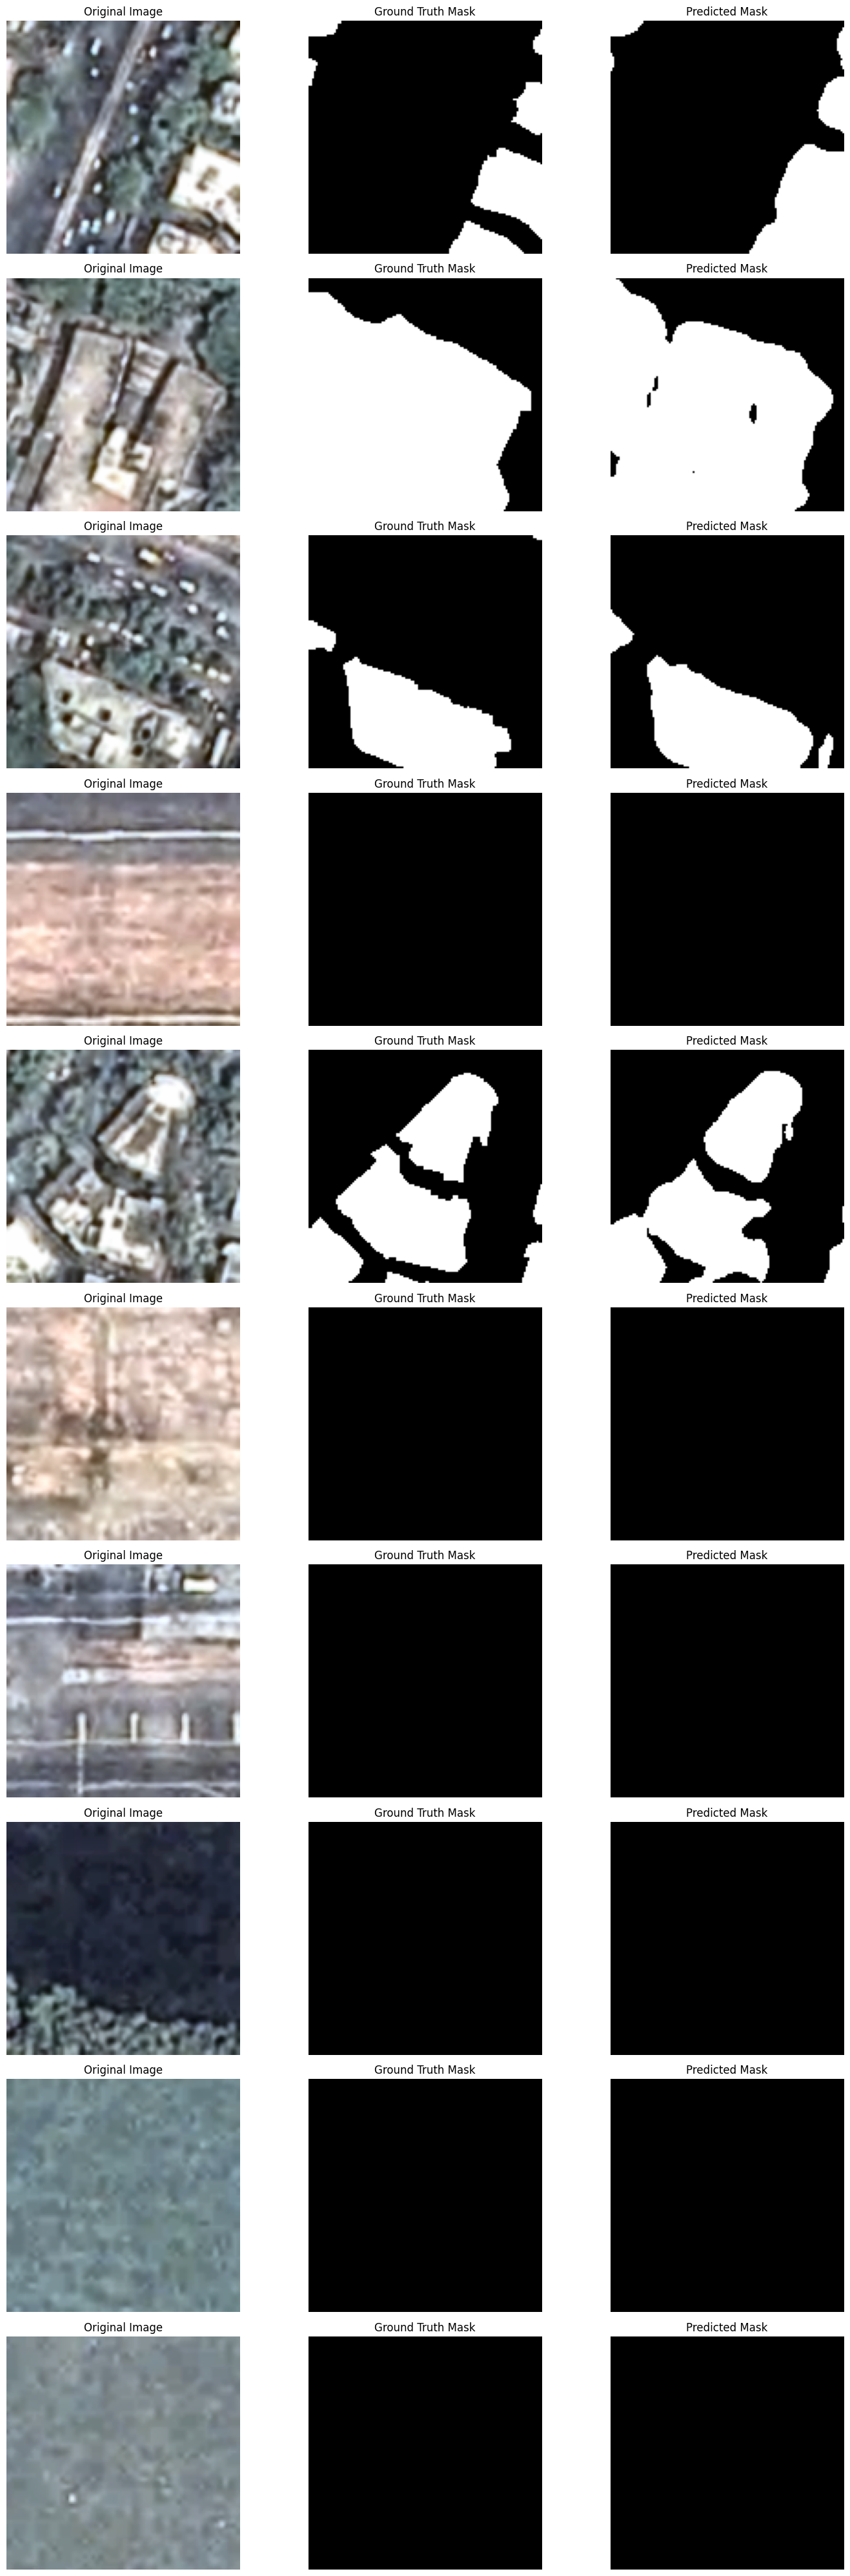

Generated: 10 Visual Segmentation Examples


In [18]:
import torch
from torch.utils.data import DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import os
import numpy as np
import cv2
from tqdm import tqdm

# Import utilities and the plotting function from main_workflow.py
# NOTE: You need to copy the entire plot_results function from main_workflow.py 
# into this script or ensure it's importable. For simplicity, I'll include the 
# key components needed for the function to run.

# ----------------------------------------------------------------------
# 1. Imports from utility files (Make sure these files are in the same directory)
# ----------------------------------------------------------------------
from data_utils import SegmentationDataset, enhance_image_dip
from model_utils import get_model, combined_loss, iou_score 

from analyse_utils import plot_results # <-- Clean import now!
from main_work import validate_epoch# Assuming you made plot_results importable

# ----------------------------------------------------------------------
# 2. Configuration (Must match the training script settings)
# ----------------------------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 16 
IMAGE_SIZE = 128 # Must match the size used during training
MODEL_PATH = "best_model.pth" # The checkpoint saved by main_workflow.py

# --- Data Path Placeholders (Must match the training script settings) ---
BASE_PATH = "../Dataset/Prepared_Dataset" # Adjust this path as necessary
VAL_IMG_DIR = os.path.join(BASE_PATH, "test/images")
VAL_MASK_DIR = os.path.join(BASE_PATH, "test/masks")

# ----------------------------------------------------------------------
# 3. Validation Transform (Must match the training script settings)
# ----------------------------------------------------------------------
val_transform = A.Compose([
    A.Resize(height=IMAGE_SIZE, width=IMAGE_SIZE),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2()
])

# ----------------------------------------------------------------------
# 4. Main Analysis Logic
# ----------------------------------------------------------------------
def analyze_and_plot_best_model():
    # 4.1 Check for model and data
    if not os.path.exists(MODEL_PATH):
        print(f"ERROR: Model checkpoint '{MODEL_PATH}' not found. Did you run the training script first?")
        return
    if not os.path.exists(VAL_IMG_DIR):
        print(f"ERROR: Data path not found: {VAL_IMG_DIR}")
        return

    # 4.2 Setup Model and Load Weights
    print(f"Loading best model from {MODEL_PATH}...")
    model = get_model(DEVICE)
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    model.eval()
    
    # 4.3 Setup DataLoader
    val_dataset = SegmentationDataset(VAL_IMG_DIR, VAL_MASK_DIR, transform=val_transform)
    val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
    
    # 4.4 Run Validation (Inference)
    print("Running inference on the validation set...")
    # NOTE: We only care about the predictions and masks here
    # val_loss, val_miou, final_val_preds, final_val_masks = validate_epoch(model, val_loader)
    # Corrected line in your analysis script:
    _, _, final_val_preds, final_val_masks = validate_epoch(model, val_loader)

    # print(f"\nInference complete. Best Model mIoU on Validation Set: {val_miou:.4f}")

    # 4.5 Plotting (Visualization and Metrics)
    # Since we are only running the final analysis, we pass empty lists for history plots
    plot_results(
        train_losses=[], # Empty, as we are not plotting history
        val_losses=[],   # Empty, as we are not plotting history
        val_mious=[],    # Empty, as we are not plotting history
        all_val_preds=final_val_preds,
        all_val_masks=final_val_masks,
        val_dataset=val_dataset,
        num_sample_images=10 
    )

if __name__ == '__main__':
    try:
        analyze_and_plot_best_model()
    except Exception as e:
        print(f"An unexpected error occurred during analysis: {e}")